# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu, ttest_ind

# Загрузка исторических данных
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

# Первые 5 строк
display(sessions_history.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [2]:
# Количество уникальных сессий для каждого пользователя
user_sessions_count = sessions_history.groupby('user_id')['session_id'].nunique().reset_index()
user_sessions_count.columns = ['user_id', 'session_count']
user_sessions_count = user_sessions_count.sort_values('session_count', ascending=False)

# Пользователь с наибольшим количеством сессий
top_user = user_sessions_count.iloc[0]['user_id']
print(f"Пользователь с наибольшим количеством сессий: {top_user}")
print(f"Количество сессий: {user_sessions_count.iloc[0]['session_count']}")

# Данные этого пользователя
display(sessions_history[sessions_history['user_id'] == top_user])

Пользователь с наибольшим количеством сессий: 10E0DEFC1ABDBBE0
Количество сессий: 10


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

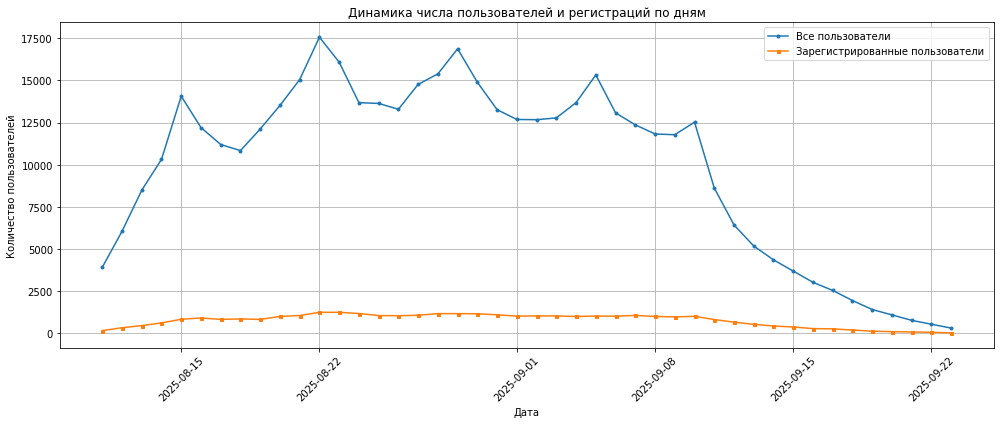

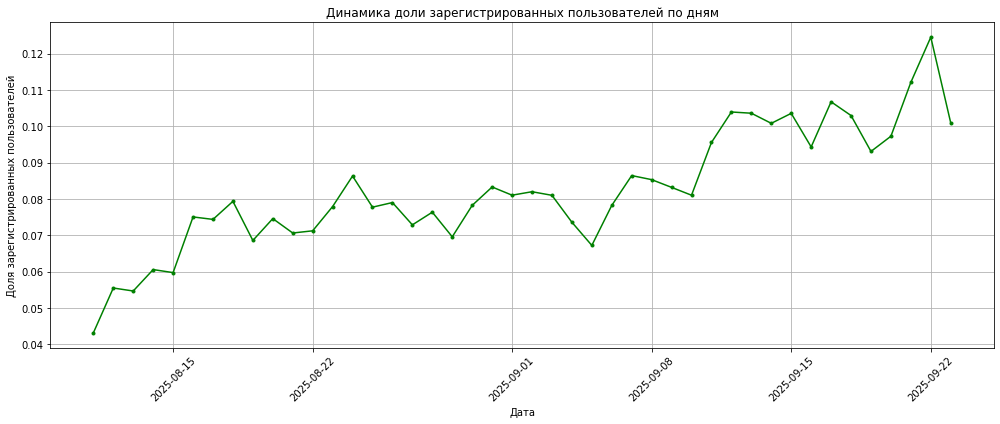

In [3]:
# Преобразование дат
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])
sessions_history['install_date'] = pd.to_datetime(sessions_history['install_date'])

# Агрегация по дням
daily_users = sessions_history.groupby('session_date').agg(
    total_users=('user_id', 'nunique'),
    registered_users=('registration_flag', 'sum')
).reset_index()

# Построение графиков
plt.figure(figsize=(14, 6))
plt.plot(daily_users['session_date'], daily_users['total_users'], label='Все пользователи', marker='o', markersize=3)
plt.plot(daily_users['session_date'], daily_users['registered_users'], label='Зарегистрированные пользователи', marker='s', markersize=3)
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.title('Динамика числа пользователей и регистраций по дням')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Доля зарегистрированных пользователей
daily_users['registered_share'] = daily_users['registered_users'] / daily_users['total_users']

plt.figure(figsize=(14, 6))
plt.plot(daily_users['session_date'], daily_users['registered_share'], color='green', marker='o', markersize=3)
plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных пользователей')
plt.title('Динамика доли зарегистрированных пользователей по дням')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

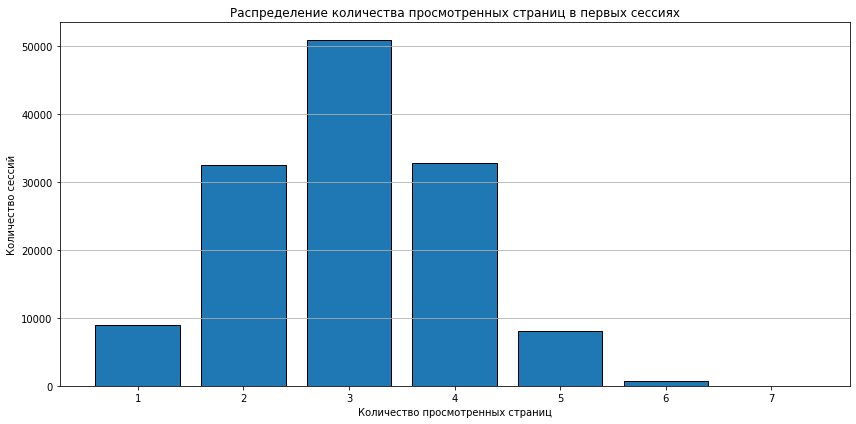

In [4]:
# Первые сессии пользователей
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Количество первых сессий для каждого значения page_counter
page_counter_distribution = first_sessions['page_counter'].value_counts().sort_index()

# Построение столбчатой диаграммы
plt.figure(figsize=(12, 6))
plt.bar(page_counter_distribution.index, page_counter_distribution.values, width=0.8, edgecolor='black')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество сессий')
plt.title('Распределение количества просмотренных страниц в первых сессиях')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

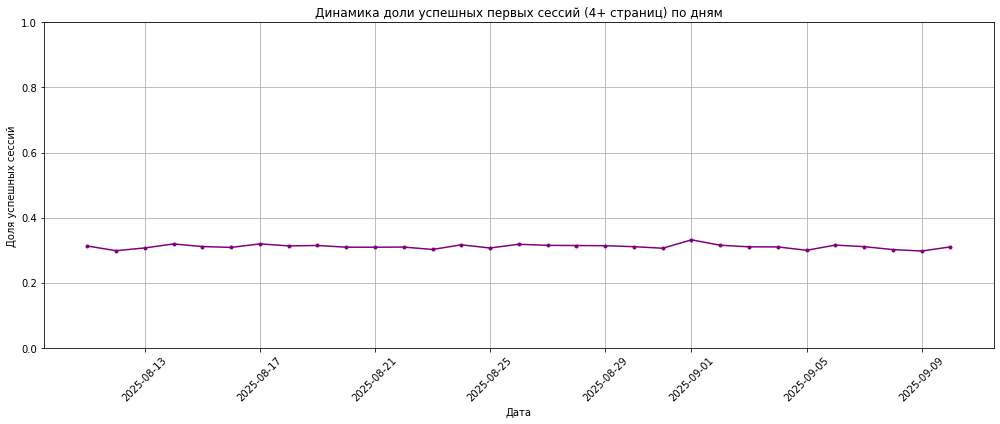

In [5]:
# Создание столбца good_session
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

# Только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Доля успешных сессий по дням
daily_good_share = first_sessions.groupby('session_date')['good_session'].mean().reset_index()

# Построение графика
plt.figure(figsize=(14, 6))
plt.plot(daily_good_share['session_date'], daily_good_share['good_session'], color='purple', marker='o', markersize=3)
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.title('Динамика доли успешных первых сессий (4+ страниц) по дням')
plt.grid(True)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [6]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
relative_mde = 0.03  # Минимальный детектируемый эффект
absolute_mde = p * relative_mde

effect_size = proportion_effectsize(p, p + absolute_mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [7]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = daily_users['total_users'].mean()
print(f"Среднее количество пользователей в день: {avg_daily_users:.0f}")

# Доля трафика, идущая в каждую группу (обычно 50/50)
traffic_per_group = 0.5

# Количество пользователей в день, попадающих в ОДНУ группу
daily_users_per_group = avg_daily_users * traffic_per_group
print(f"Среднее количество пользователей в день на одну группу: {daily_users_per_group:.0f}")

# Длительность теста = размер выборки / дневной трафик на группу
test_duration = ceil(sample_size / daily_users_per_group)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Среднее количество пользователей в день: 9907
Среднее количество пользователей в день на одну группу: 4954
Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

Количество уникальных пользователей в группах:
test_group
A    1477
B    1466
Name: user_id, dtype: int64

Процентная разница: 0.74%


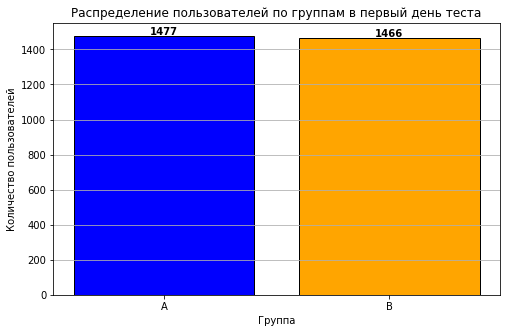

In [8]:
# Загрузка данных за первый день теста
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

# Количество уникальных пользователей в каждой группе
users_in_groups = sessions_test_part.groupby('test_group')['user_id'].nunique()
print("Количество уникальных пользователей в группах:")
print(users_in_groups)

# Процентная разница
diff_percent = 100 * abs(users_in_groups['A'] - users_in_groups['B']) / users_in_groups['A']
print(f"\nПроцентная разница: {diff_percent:.2f}%")

# Визуализация
plt.figure(figsize=(8, 5))
plt.bar(users_in_groups.index, users_in_groups.values, color=['blue', 'orange'], edgecolor='black')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по группам в первый день теста')
for i, v in enumerate(users_in_groups.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.grid(True, axis='y')
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [9]:
# Пользователи в группе A
users_A = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].unique())
# Пользователи в группе B
users_B = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].unique())

# Пересечение
intersection = users_A & users_B
print(f"Количество пользователей, попавших в обе группы: {len(intersection)}")

if len(intersection) == 0:
    print("Пересечений нет. Группы независимы.")
else:
    print(f"Найдены пересечения: {intersection}")

Количество пользователей, попавших в обе группы: 0
Пересечений нет. Группы независимы.


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


Распределение устройств в группе A (по пользователям):
Android    0.4441
PC         0.2498
iPhone     0.2004
Mac        0.1056
Name: device, dtype: float64

Распределение устройств в группе B (по пользователям):
Android    0.4557
PC         0.2599
iPhone     0.1835
Mac        0.1010
Name: device, dtype: float64


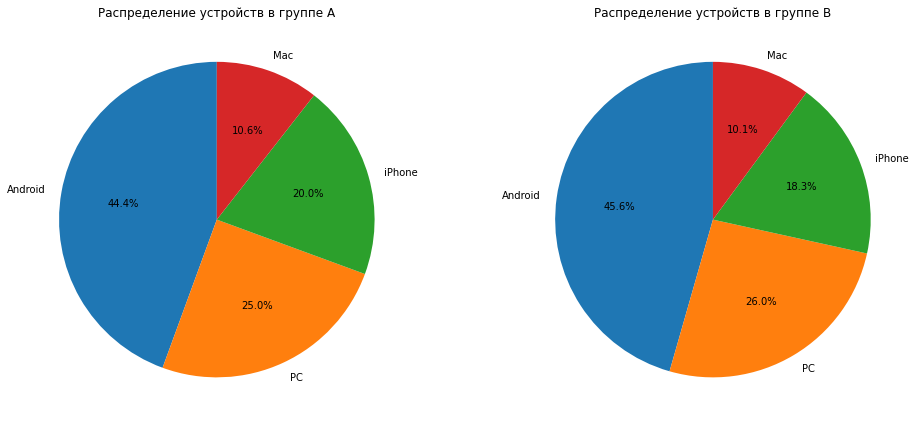

In [10]:
# Получаем уникальных пользователей с их устройствами и группами
unique_users_devices = sessions_test_part[['user_id', 'test_group', 'device']].drop_duplicates()
# Распределение по устройствам в группе A (по УНИКАЛЬНЫМ пользователям)
device_dist_A = unique_users_devices[unique_users_devices['test_group'] == 'A']['device'].value_counts(normalize=True)
# Распределение по устройствам в группе B
device_dist_B = unique_users_devices[unique_users_devices['test_group'] == 'B']['device'].value_counts(normalize=True)

print("Распределение устройств в группе A (по пользователям):")
print(device_dist_A.round(4))
print("\nРаспределение устройств в группе B (по пользователям):")
print(device_dist_B.round(4))

# Построение диаграмм
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(device_dist_A.values, labels=device_dist_A.index, autopct='%1.1f%%', 
            startangle=90, normalize=False)
axes[0].set_title('Распределение устройств в группе A')

axes[1].pie(device_dist_B.values, labels=device_dist_B.index, autopct='%1.1f%%', 
            startangle=90, normalize=False)
axes[1].set_title('Распределение устройств в группе B')

plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

Распределение регионов в группе A (по пользователям):
CIS     0.4360
MENA    0.4123
EU      0.1517
Name: region, dtype: float64

Распределение регионов в группе B (по пользователям):
CIS     0.440
MENA    0.412
EU      0.148
Name: region, dtype: float64


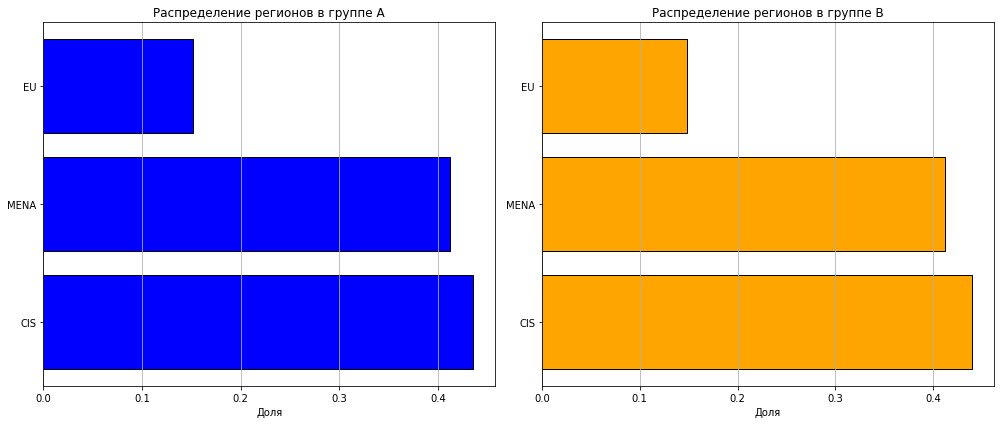

In [11]:
# Получаем уникальных пользователей с их регионами и группами
unique_users_regions = sessions_test_part[['user_id', 'test_group', 'region']].drop_duplicates()

# Распределение по регионам в группе A (по УНИКАЛЬНЫМ пользователям)
region_dist_A = unique_users_regions[unique_users_regions['test_group'] == 'A']['region'].value_counts(normalize=True)
# Распределение по регионам в группе B
region_dist_B = unique_users_regions[unique_users_regions['test_group'] == 'B']['region'].value_counts(normalize=True)

print("Распределение регионов в группе A (по пользователям):")
print(region_dist_A.round(4))
print("\nРаспределение регионов в группе B (по пользователям):")
print(region_dist_B.round(4))

# Построение горизонтальных столбчатых диаграмм
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(region_dist_A.index, region_dist_A.values, color='blue', edgecolor='black')
axes[0].set_xlabel('Доля')
axes[0].set_title('Распределение регионов в группе A')
axes[0].grid(True, axis='x')

axes[1].barh(region_dist_B.index, region_dist_B.values, color='orange', edgecolor='black')
axes[1].set_xlabel('Доля')
axes[1].set_title('Распределение регионов в группе B')
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

__Вывод по результатам мониторинга A/B-теста__

1. **Различие в количестве пользователей**: 
   - Группа A: 1477 пользователей
   - Группа B: 1466 пользователей
   - Процентная разница составляет 0.74%, что является допустимым (менее 15%).
2. **Независимость выборок**: 
   - Пересечений пользователей между группами не обнаружено. Группы независимы.
3. **Распределение по устройствам**: 
   - Распределение типов устройств в группах A и B практически идентично (максимальное отклонение ~1.6%).
4. **Распределение по регионам**: 
   - Распределение регионов в группах A и B практически идентично (максимальное отклонение ~0.4%).


**Заключение**: A/B-тест проходит корректно. Группы сбалансированы по размеру, независимы, равномерно распределены как по типам устройств, так и по регионам. Можно продолжать анализ результатов эксперимента.


### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [12]:
# Загрузка данных за весь период теста
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

# Преобразование дат
sessions_test['session_date'] = pd.to_datetime(sessions_test['session_date'])

# Создание столбца good_session
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

# Только первые сессии
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

print(f"Всего записей в тестовых данных: {len(sessions_test)}")
print(f"Первых сессий: {len(first_sessions_test)}")

Всего записей в тестовых данных: 100005
Первых сессий: 30578


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

__Формулировка гипотез__

**Нулевая гипотеза (H₀)**: 
Новый алгоритм рекомендаций не влияет на вовлечённость пользователей. 
Доля успешных первых сессий (с просмотром 4+ страниц) в тестовой группе (B) равна доле успешных первых сессий в контрольной группе (A).

**Альтернативная гипотеза (H₁)**: 
Новый алгоритм рекомендаций увеличивает вовлечённость пользователей. 
Доля успешных первых сессий в тестовой группе (B) больше, чем в контрольной группе (A).

**Целевая метрика**: Доля успешных первых сессий (good_session = 1 для session_number = 1)

**Прокси-метрики** (если бы отслеживали):
- Количество просмотренных страниц за сессию
- Время, проведённое в приложении
- Количество сессий на пользователя

**Барьерные метрики** (если бы отслеживали):
- Частота ошибок/вылетов приложения
- Время загрузки контента
- Количество жалоб пользователей

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [13]:
# Расчёт доли успешных сессий по группам
group_A = first_sessions_test[first_sessions_test['test_group'] == 'A']
group_B = first_sessions_test[first_sessions_test['test_group'] == 'B']

success_rate_A = group_A['good_session'].mean()
success_rate_B = group_B['good_session'].mean()
difference = success_rate_B - success_rate_A

print(f"Доля успешных сессий в группе A: {success_rate_A:.4f} ({success_rate_A*100:.2f}%)")
print(f"Доля успешных сессий в группе B: {success_rate_B:.4f} ({success_rate_B*100:.2f}%)")
print(f"Разница (B - A): {difference:.4f} ({difference*100:.2f}%)")

Доля успешных сессий в группе A: 0.3157 (31.57%)
Доля успешных сессий в группе B: 0.3147 (31.47%)
Разница (B - A): -0.0011 (-0.11%)


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [14]:
# Размеры выборок A и B
n_a = group_A.shape[0]
n_b = group_B.shape[0]
# Количество успехов (good_session = 1) в группах A и B
m_a = group_A['good_session'].sum()
m_b = group_B['good_session'].sum()

# Доли успехов для каждой группы
p_a = m_a / n_a
p_b = m_b / n_b

# Проверка предпосылки о достаточном количестве данных
if (p_a * n_a > 10) and ((1 - p_a) * n_a > 10) and (p_b * n_b > 10) and ((1 - p_b) * n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')
print()

alpha = 0.05  # Уровень значимости


# Z-тест пропорций
# alternative='larger' проверяет, что p_b > p_a (доля в группе B больше)
stat_ztest, p_value_ztest = proportions_ztest(
    [m_b, m_a],  # сначала группа B, потом группа A
    [n_b, n_a],
    alternative='larger'  # H₁: p_B > p_A
)

print(f"Z-статистика: {stat_ztest}")
print(f"p-value = {p_value_ztest}")
print()

if p_value_ztest > alpha:
    print(f"p-value = {p_value_ztest:.6f} > {alpha}")
    print('Нулевая гипотеза находит подтверждение!')
    text_interpretation = 'не изменилось'
else:
    print(f"p-value = {p_value_ztest:.6f} < {alpha}")
    print('Нулевая гипотеза не находит подтверждения!')
    text_interpretation = 'увеличилось'

print(f'\nПри внедрении нового алгоритма рекомендаций количество успешных сессий {text_interpretation}')

Предпосылка о достаточном количестве данных выполняется!

Z-статистика: -0.19768021528115556
p-value = 0.5783523649187868

p-value = 0.578352 > 0.05
Нулевая гипотеза находит подтверждение!

При внедрении нового алгоритма рекомендаций количество успешных сессий не изменилось


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

__Вывод по результатам A/B-эксперимента__
1. Характеристики проведённого эксперимента:

- Целевая метрика: Доля успешных первых сессий (просмотр 4 и более страниц за первую сессию).

- Количество пользователей: В анализ включены данные пользователей, совершивших первую сессию за период теста.

- Контрольная группа (A): 15 238 пользователей.

- Тестовая группа (B): 15 340 пользователей.

- Длительность эксперимента: Тест проводился с 2025-10-14 по 2025-11-02 (20 дней), что превышает расчётную минимальную длительность (2 дня) и позволяет считать результаты устойчивыми.

2. Влияние на ключевую метрику:

- Доля успешных сессий в контрольной группе (A) составила 31.57%.

- Доля успешных сессий в тестовой группе (B) составила 31.47%.

- Разница между группами составила -0.11% (т.е. в тестовой группе показатель оказался даже немного ниже, чем в контрольной).

3. Статистическая значимость:

- Проведён односторонний z-тест пропорций (проверялась гипотеза, что результат в группе B лучше, чем в A).

- Уровень значимости: α = 0.05.

- Полученное p-value = 0.578.

- Поскольку p-value > 0.05, нулевая гипотеза подтверждается. Это означает, что наблюдаемое различие статистически незначимо.

4. Итоговое заключение и рекомендация:

- Новый алгоритм рекомендаций не оказал статистически значимого влияния на вовлечённость пользователей в первой сессии. Доля пользователей, просматривающих 4 и более страниц, не изменилась.

__Рекомендация команде разработки:__ Отклонить внедрение нового алгоритма рекомендаций. На основе имеющихся данных нет оснований утверждать, что он улучшает пользовательский опыт относительно целевой метрики. Рекомендуется продолжить анализ причин, почему алгоритм не дал ожидаемого эффекта, и рассмотреть альтернативные гипотезы для повышения вовлечённости.